## Hypothetical Document Embedding (HyDE) in Document Retrieval

### Overview
This code implements a Hypothetical Document Embedding (HyDE) system for document retrieval. HyDE is an innovative approach that transforms query questions into hypothetical documents containing the answer, aiming to bridge the gap between query and document distributions in vector space.

### Motivation
Traditional retrieval methods often struggle with the semantic gap between short queries and longer, more detailed documents. HyDE addresses this by expanding the query into a full hypothetical document, potentially improving retrieval relevance by making the query representation more similar to the document representations in the vector space.

### Key Components
1. PDF processing and text chunking
2. Vector store creation using FAISS and OpenAI embeddings
3. Language model for generating hypothetical documents
4. Custom HyDERetriever class implementing the HyDE technique

### Method Details
#### Document Preprocessing and Vector Store Creation
1. The PDF is processed and split into chunks.
2. A FAISS vector store is created using OpenAI embeddings for efficient similarity search.
#### Hypothetical Document Generation
1. A language model is used to generate a hypothetical document that answers the given query.
2. The generation is guided by a prompt template that ensures the hypothetical document is detailed and matches the chunk size used in the vector store.
#### Retrieval Process
The `HyDERetriever` class implements the following steps:
1. Generate a hypothetical document from the query using the language model.
2. Use the hypothetical document as the search query in the vector store.
3. Retrieve the most similar documents to this hypothetical document.
### Key Features
1. Query Expansion: Transforms short queries into detailed hypothetical documents.
2. Flexible Configuration: Allows adjustment of chunk size, overlap, and number of retrieved documents.
3. Integration with OpenAI Models: Uses GPT-4 for hypothetical document generation and OpenAI embeddings for vector representation.

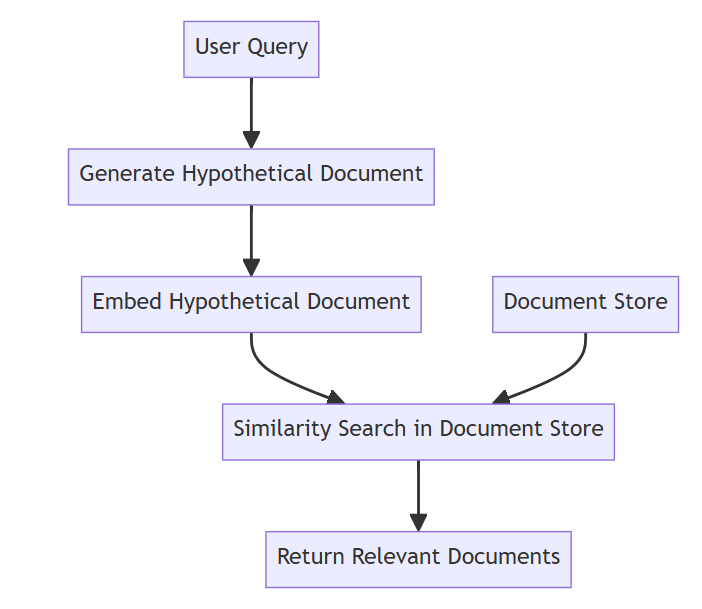

### Imports

In [14]:
import sys
from dotenv import load_dotenv
load_dotenv()
sys.path.append('../')  # Go up one level
from helper_functions import *
from langchain_groq import ChatGroq

### Define Document path

In [15]:
from pathlib import Path
p = Path.cwd().parent / "data" / "Understanding_Climate_Change.pdf"
print(p, p.exists())
path = str(p)  # use this for encode_pdf(...)

c:\Users\birok\Python\MLOPs\Langchain-Langgraph-Tutorials\data\Understanding_Climate_Change.pdf True


### Define the HyDe retriever class - creating vector store, generating hypothetical document, and retrieving

In [23]:
class HyDERetriever:
    def __init__(self, files_path, chunk_size=500, chunk_overlap=100):
        self.llm= ChatGroq(temperature=0, model_name="openai/gpt-oss-120b", max_tokens=4000)
        self.embeddings= BedrockEmbeddings(model_id='amazon.titan-embed-text-v2:0')
        self.chunk_size=chunk_size
        self.chunk_overlap= chunk_overlap
        self.vectorstore= encode_pdf(files_path, chunk_size=self.chunk_size, chunk_overlap=self.chunk_overlap)

        self.hyde_prompt= PromptTemplate(
            input_variables=["query", "chunk_size"],
            template="""Given the question '{query}', generate a detailed hypothetical document that answers it."""
        )
        self.hyde_chain=self.hyde_prompt | self.llm

    def generate_hypothetical_document(self, query):
        input_variables = {"query": query, "chunk_size": self.chunk_size}
        
        response = self.hyde_chain.invoke(input_variables)
        hypothetical_doc = getattr(response, "content", "")

        # Minimal fix
        if not hypothetical_doc.strip():
            print("Empty HyDE output, using original query instead")
            return query
        return hypothetical_doc
    
    def retrieve(self, query, k=3):
        hypothetical_doc= self.generate_hypothetical_document(query)
        similar_docs= self.vectorstore.similarity_search(hypothetical_doc, k=k)
        return similar_docs, hypothetical_doc

### Create a HyDE retriever instance

In [24]:
retriever= HyDERetriever(path)

### Demostrate a use case

In [25]:
test_query = "What is the main cause of climate change?"
results, hypothetical_doc = retriever.retrieve(test_query)

In [31]:
print("Query:", test_query)
print("\nHyDE Doc:\n", hypothetical_doc)
print("\nRetreived Docs\n")
for d in results:
    print(d.page_content[:200], "\n")

Query: What is the main cause of climate change?

HyDE Doc:
 **Document Title:**  
**The Primary Driver of Contemporary Climate Change: An In‑Depth Examination of Anthropogenic Greenhouse Gas Emissions**

---

### Abstract
The overwhelming scientific consensus identifies the combustion of fossil fuels and the resulting increase in atmospheric concentrations of carbon dioxide (CO₂) as the principal cause of the rapid climate change observed since the mid‑20th century. This document synthesizes peer‑reviewed research, climate model outputs, and observational data to explain why anthropogenic greenhouse gas (GHG) emissions dominate the climate system’s energy balance, how they interact with natural climate variability, and why alternative hypotheses (e.g., solar variability, volcanic activity) are insufficient to account for the observed warming trend.

---

## 1. Introduction
Climate change refers to long‑term alterations in temperature, precipitation, wind patterns, and other aspects of